# Tutorial: Plot Rover Positions

This notebook focuses on the rover positions stored in the RF xarray.

The extractor already removed:
- invalid or missing rover samples
- duplicate consecutive rover positions within the configured tolerance

This version of the tutorial can merge multiple experiment IDs into one combined set of valid rover positions.


In [1]:
# Optional: uncomment when this Jupyter kernel misses the plotting dependencies.
# import sys
# !{sys.executable} -m pip install matplotlib numpy requests xarray pyyaml


In [2]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "csi_plot_utils.py").exists():
    NOTEBOOK_DIR = (NOTEBOOK_DIR / "processing").resolve()

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)


In [3]:
REQUESTED_EXPERIMENT_IDS = None  # Example: ["EXP003", "EXP005"]. None means: use all experiment IDs in the opened dataset.
DATASET_PATH = None  # Set this to a specific .nc file when needed.


In [4]:
if REQUESTED_EXPERIMENT_IDS is None:
    ds, dataset_path = csi.open_dataset(dataset_path=DATASET_PATH)
    EXPERIMENT_IDS = csi.available_experiment_ids(ds)
else:
    EXPERIMENT_IDS = csi.normalize_experiment_ids(REQUESTED_EXPERIMENT_IDS)
    ds, dataset_path = csi.open_dataset(experiment_id=EXPERIMENT_IDS, dataset_path=DATASET_PATH)

print(f"Loaded dataset: {dataset_path}")
print(f"Selected experiment IDs: {EXPERIMENT_IDS}")
csi.print_experiment_overview(ds, EXPERIMENT_IDS)


Loaded dataset: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\results\csi_EXP003__EXP005__EXP006__EXP007_20260402_145021.nc
Selected experiment IDs: ['EXP003', 'EXP005', 'EXP006', 'EXP007']
EXP003: cycles_with_csi=529, valid_positions=529, first_csi_cycle=1, last_csi_cycle=529
EXP005: cycles_with_csi=777, valid_positions=777, first_csi_cycle=1, last_csi_cycle=777
EXP006: cycles_with_csi=238, valid_positions=238, first_csi_cycle=1, last_csi_cycle=238
EXP007: cycles_with_csi=360, valid_positions=358, first_csi_cycle=1, last_csi_cycle=360


## Inspect The Merged Valid Position Rows

The helper below keeps only rows with valid rover coordinates and merges the selected experiment IDs into one measurement table.


In [5]:
positions = csi.positions_for_experiments(ds, EXPERIMENT_IDS)
print(f"Valid rover positions across the selected experiments: {positions.sizes['measurement_index']}")
positions.isel(measurement_index=slice(0, min(10, positions.sizes['measurement_index'])))


Valid rover positions across the selected experiments: 1902


<xarray.Dataset> Size: 720B
Dimensions:            (measurement_index: 10)
Coordinates:
  * measurement_index  (measurement_index) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    experiment_id      (measurement_index) <U6 240B 'EXP003' ... 'EXP003'
    cycle_id           (measurement_index) int64 80B 1 2 3 4 5 6 7 8 9 10
    rover_x            (measurement_index) float64 80B 1.918 2.541 ... 2.534
    rover_y            (measurement_index) float64 80B 2.865 2.254 ... 3.213
    rover_z            (measurement_index) float64 80B 0.7394 0.7401 ... 0.7428
    csi_host_count     (measurement_index) int64 80B 42 42 42 42 ... 42 42 42 42
Attributes:
    experiment_ids:  ['EXP003', 'EXP005', 'EXP006', 'EXP007']

## Plot The Full Trajectory As Merged Scatter Points

This plot ignores the experiment boundaries and shows all valid rover positions as one combined point cloud. The antenna positions are fetched in `csi_plot_utils.py` and overlaid as square markers.


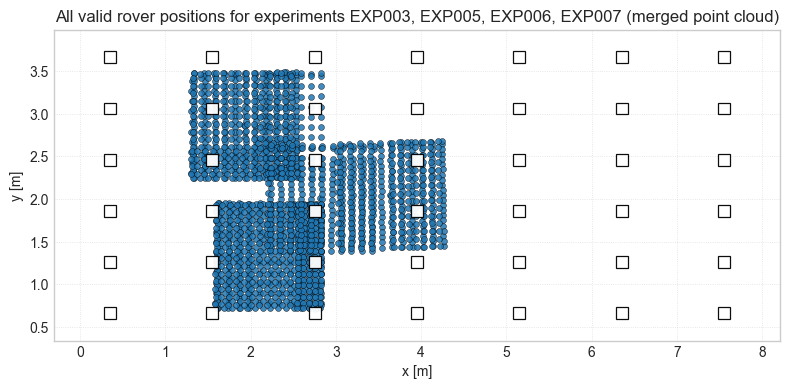

In [6]:
csi.plot_position_cloud(ds, EXPERIMENT_IDS, show_antennas=True)
plt.show()


## Plot The Per-Experiment Trajectories

Use this second plot when you still want to see the trajectory order for each experiment separately.


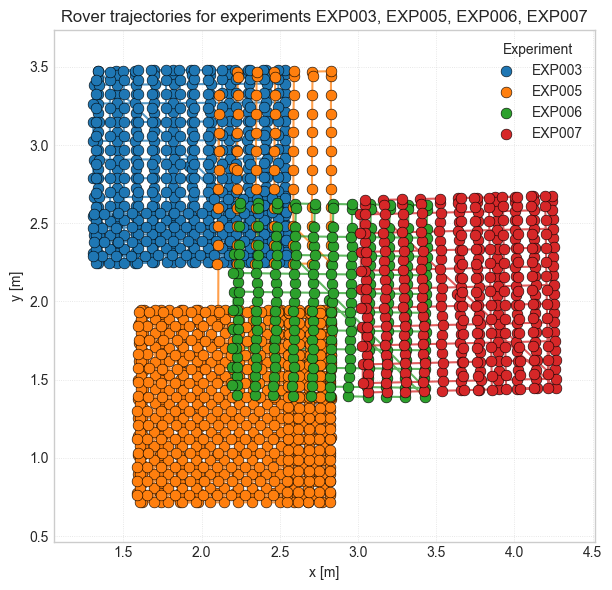

In [7]:
csi.plot_trajectory(ds, EXPERIMENT_IDS)
plt.show()


## Resolve A Physical Point To An Experiment And Cycle ID

Replace the example coordinates below with any target position in meters. The helper searches across the merged experiment IDs and returns the nearest recorded measurement.


In [8]:
target_x = float(positions['rover_x'].values[-1])
target_y = float(positions['rover_y'].values[-1])

nearest = csi.find_nearest_position_cycle(
    ds,
    EXPERIMENT_IDS,
    x=target_x,
    y=target_y,
)

print("Nearest recorded measurement for the chosen point:")
nearest


Nearest recorded measurement for the chosen point:


{'experiment_id': 'EXP007',
 'target_x': 3.656702392578125,
 'target_y': 2.660119873046875,
 'target_z': None,
 'cycle_id': 358,
 'rover_x': 3.656702392578125,
 'rover_y': 2.660119873046875,
 'rover_z': 0.746426513671875,
 'distance_m': 0.0,
 'csi_host_count': 42}